# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.alpha_search import FindAlphaSweepDS

finder = FindAlphaSweepDS(output_directory='output/draft3_run/', 
    gene_names=['DSE1', 'DSE2', 'DSE3', 'DSE4'])
finder.run_alpha_sweep(alphas=np.arange(4, 48, 4))
finder.plot_and_save_results()


In [ ]:
runner.config1.modify_alpha(30)

In [ ]:
runner.config1.plot_H()

In [2075]:
runner.deconvolve_gene_find_gamma('CLB2', replicate=1)

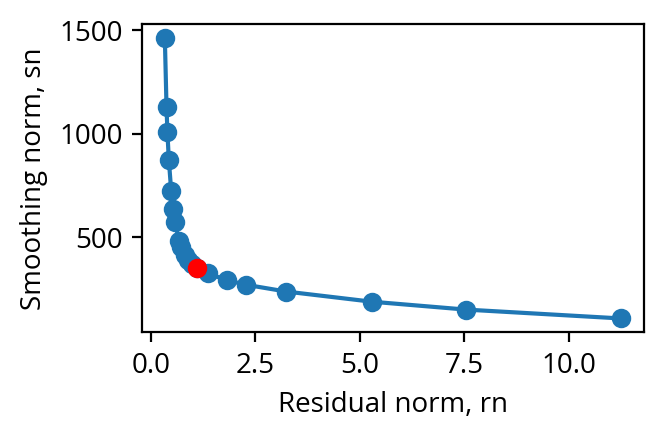

In [2076]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

Creating directory: output/draft3_run//alpha_search...
Saved figure to: output/draft3_run//alpha_search/alphas_repl1.png
Saved figure to: output/draft3_run//alpha_search/alphas_repl2.png


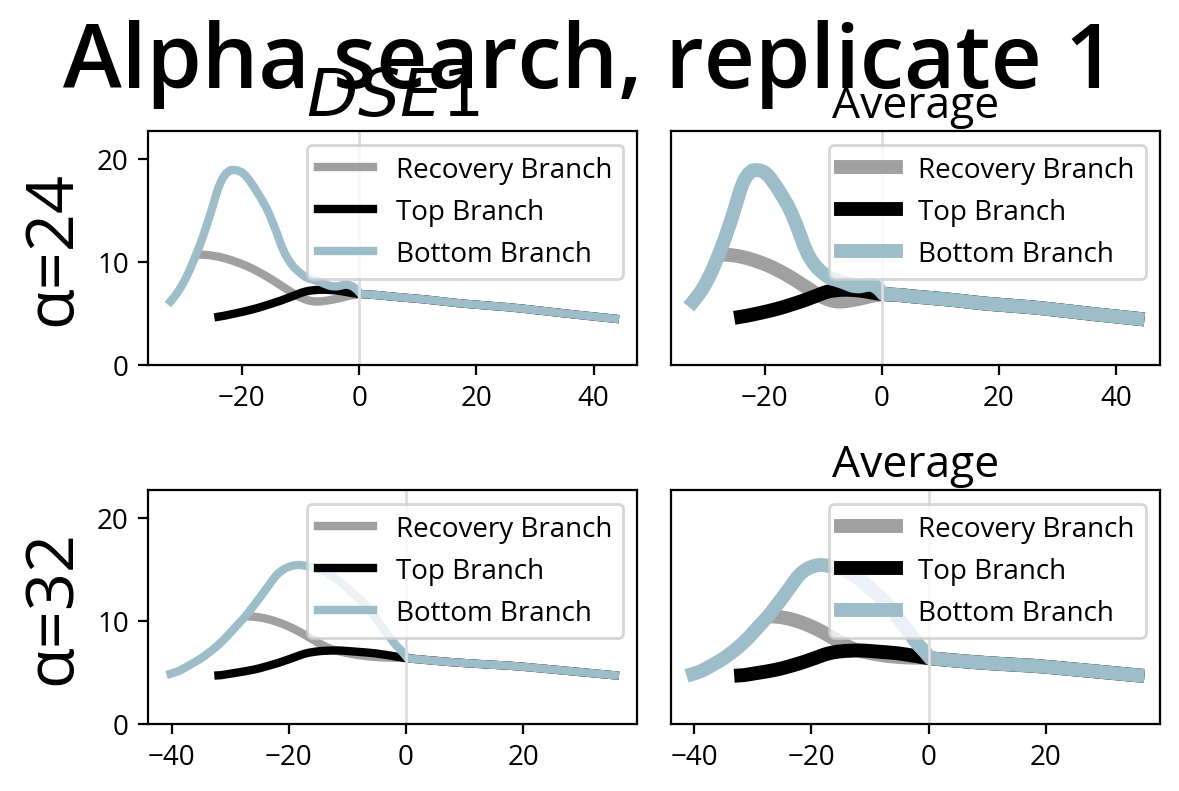

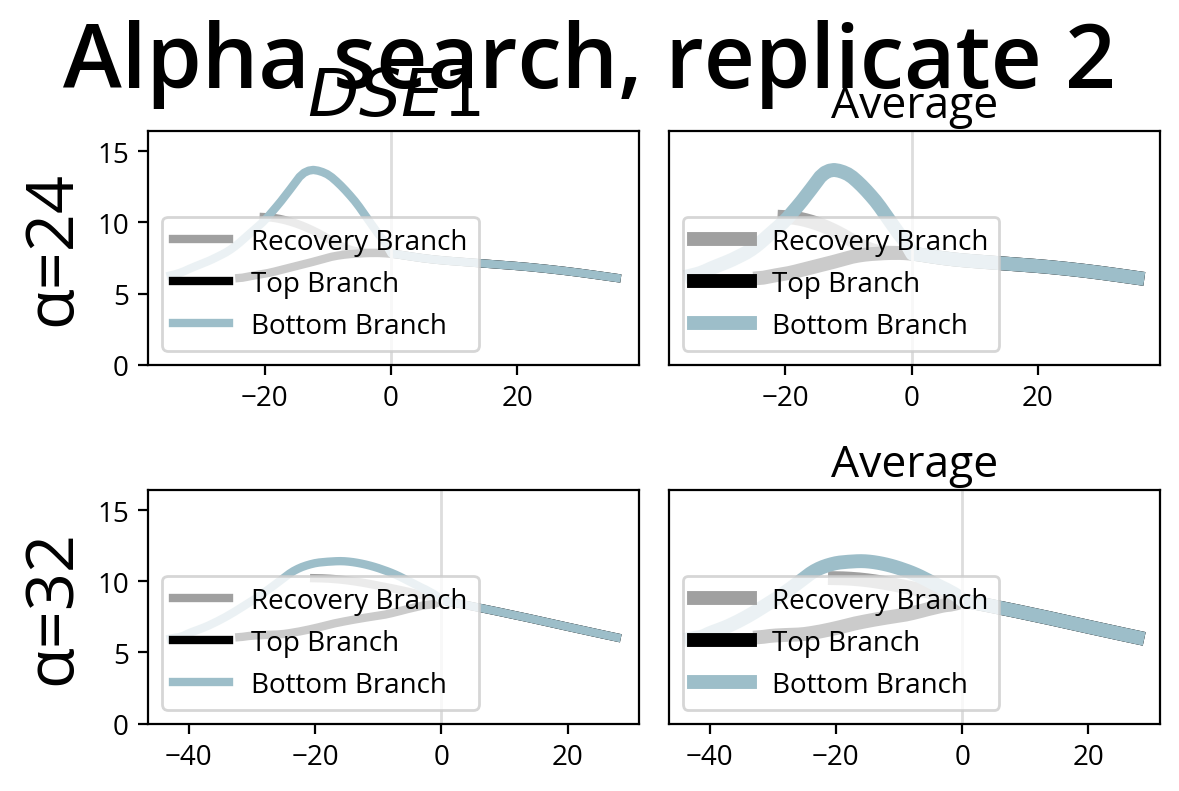

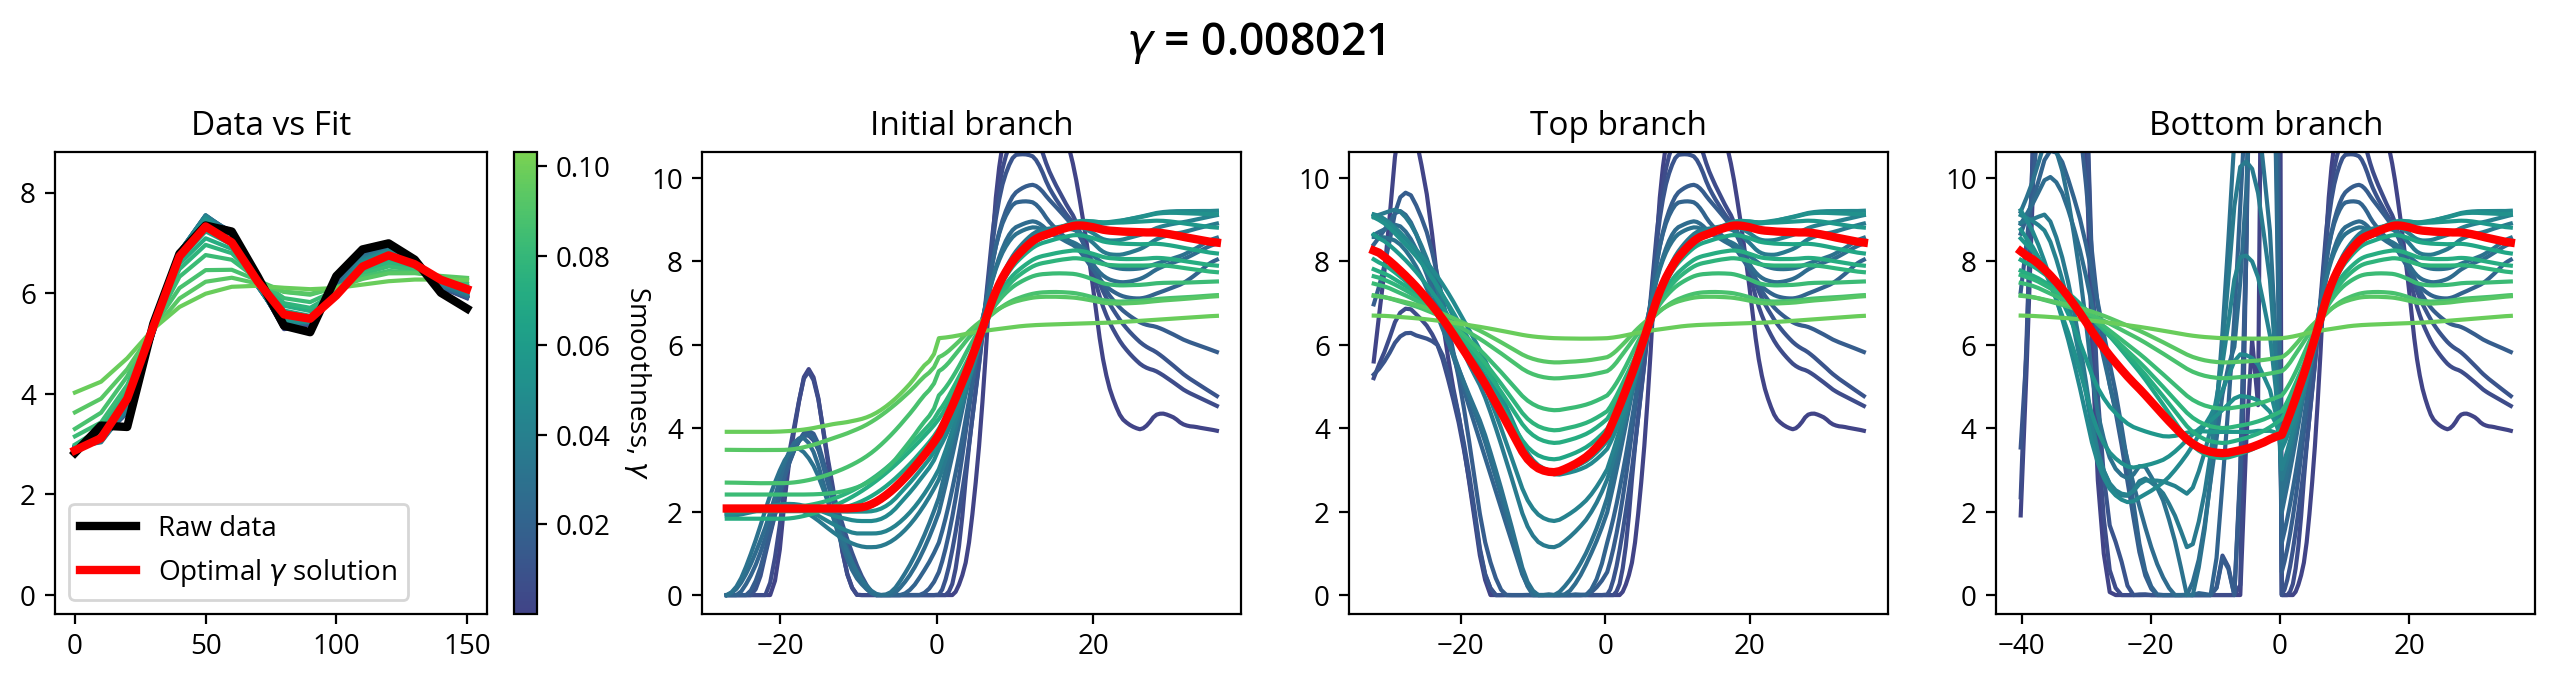

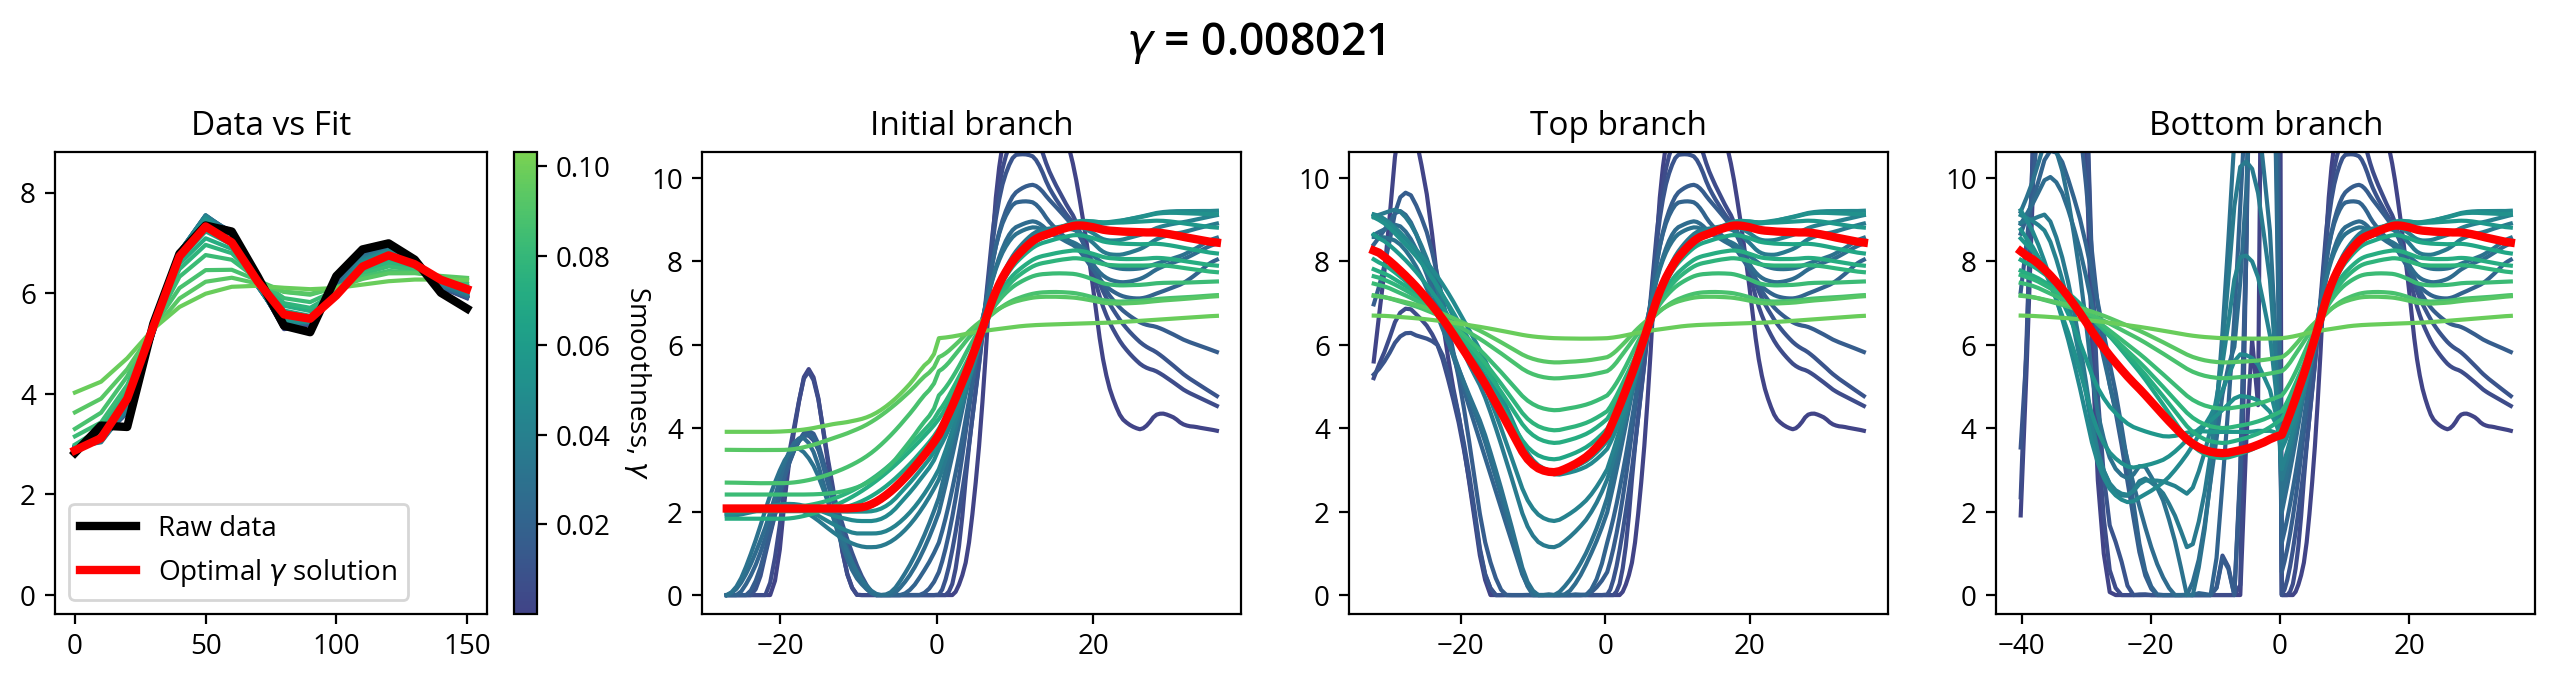

In [2077]:
runner.expression_find_gamma.plot_gamma_sweep()

In [2078]:
# Last check does the number of indices help?
from src.deconvolution_solver import DeconvolutionSolver

config = runner.expression_find_gamma.deconvolution_solver.config

test_solver = DeconvolutionSolver(config,
    runner.expression_find_gamma.deconvolution_solver.g,
    config.H, 0.008, kappa=0.0)
test_solver.verbose=True
test_solver.deconvolve()


Fit norm: 1.1107804844531368
Smoothing norm: 349.92353652015595
Initial smoothing result:  86.4084982594585
Top smoothing result:  88.17021843592049
Bottom smoothing result:  88.93632156531848


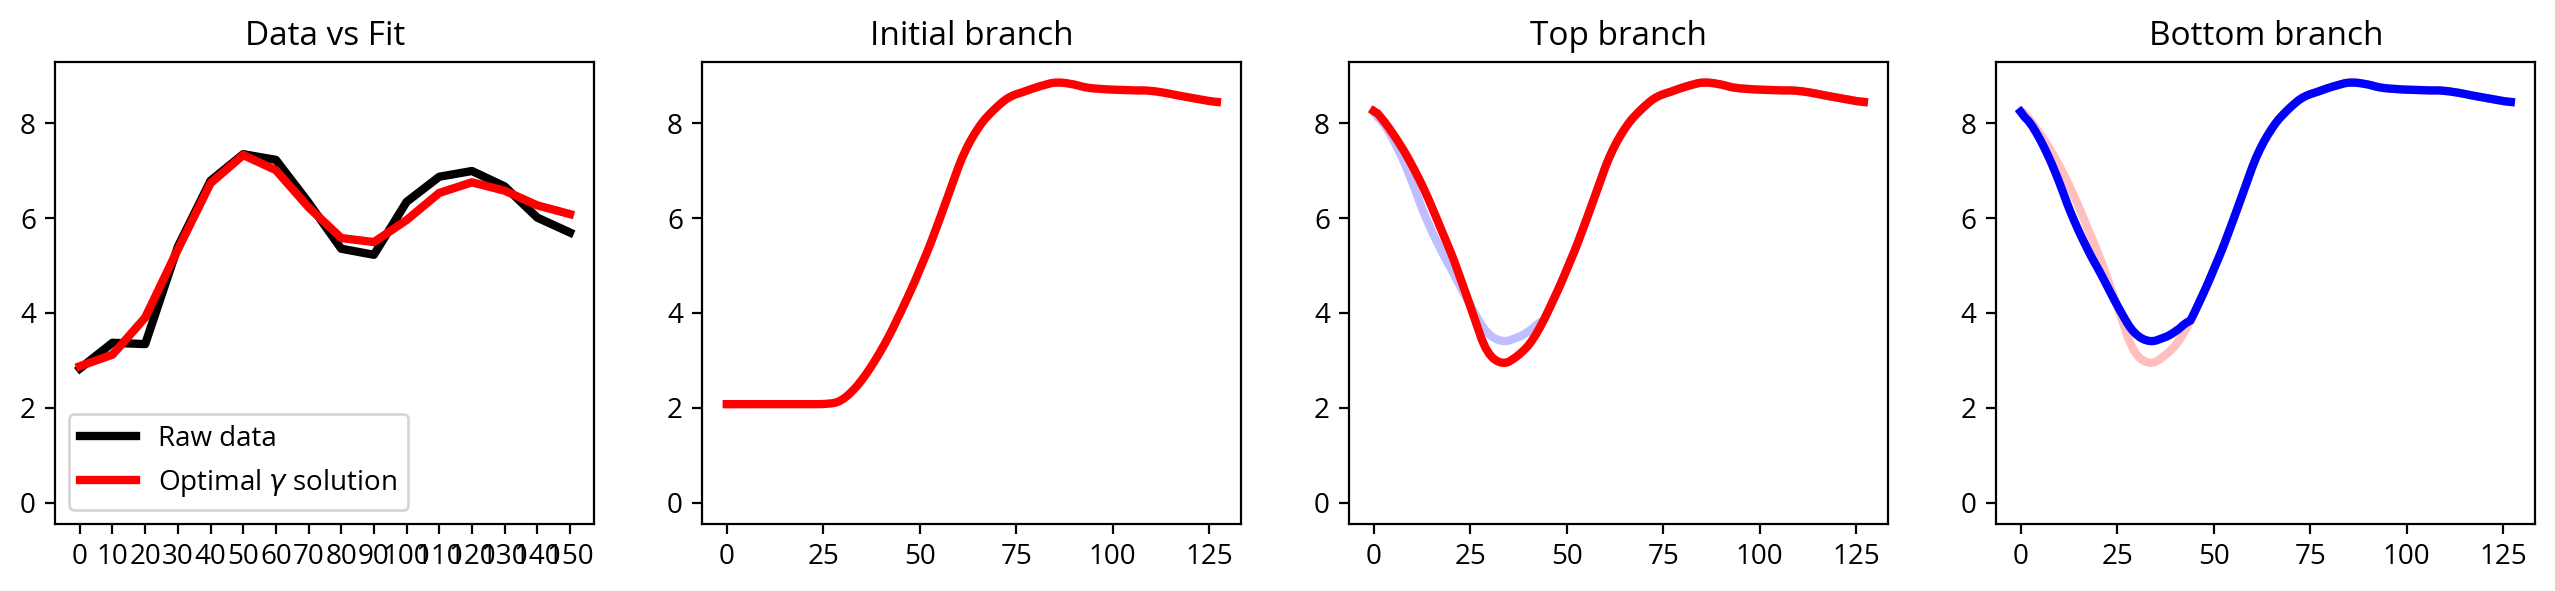

In [2079]:
test_solver.plot_fit()